In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv(r'train.csv')
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
test_df = pd.read_csv(r'test.csv')
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Training data consists of 891 rows and 12 columns  
Test data consists of 418 rows and 11 columns

### EDA

In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Youngest and oldest passengers are 0(0.42) and 80 years respectively  
**Average fare is 32 with min. as 0 and max. as 512  
Most tickets belong to second class  

In [5]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


<Axes: xlabel='Survived', ylabel='Count'>

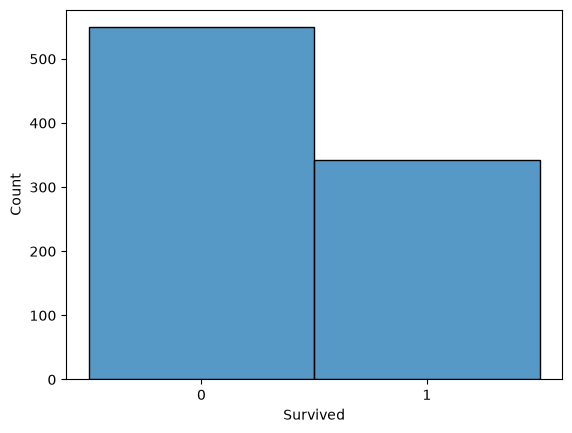

In [6]:
surv_str = train_df.Survived.astype(str)
sns.histplot(x=surv_str)

Most of the records are of passengers that did not survive

<Axes: xlabel='Pclass', ylabel='Fare'>

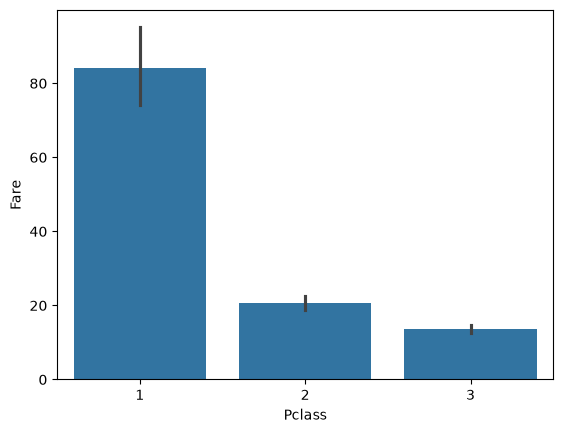

In [7]:
sns.barplot(x=train_df.Pclass, y=train_df.Fare)

Fare decreases from first to third class

In [8]:
train_df.groupby(['Survived', 'Sex'])['Sex'].count()

Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: Sex, dtype: int64

Most female survived compared to men

<Axes: xlabel='Sex', ylabel='Count'>

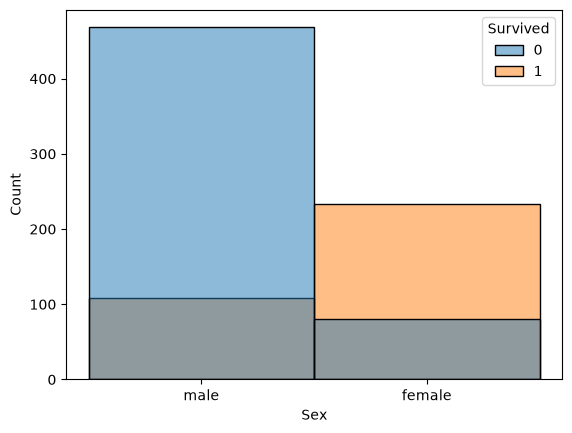

In [9]:
sns.histplot(x=train_df.Sex, hue=train_df.Survived)

In [10]:
train_df.SibSp.value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

### Data Preprocessing

Remove PassengerID

In [14]:
train_df = train_df.drop(columns='PassengerId')

In [111]:
test_df = test_df.drop(columns='PassengerId')

Extract the target(Survived)

In [17]:
y_train = train_df.loc[:, 'Survived']

In [19]:
train_df.drop(columns='Survived', inplace=True)

In [37]:
train_df.drop(columns='Ticket', inplace=True)

In [71]:
test_df.drop(columns='Ticket', inplace=True)

#### Get categorical and numeric columns

In [20]:
train_df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [165]:
train_df.Pclass = train_df.Pclass.astype('str')
test_df.Pclass = test_df.Pclass.astype('str')

In [29]:
cat_cols = train_df.select_dtypes(include='str').columns.tolist()
num_cols = train_df.select_dtypes(exclude='str').columns.tolist()

In [30]:
cat_cols, num_cols

(['Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'],
 ['Age', 'SibSp', 'Parch', 'Fare'])

#### Handle null and missing values

In [38]:
train_df.isna().sum()

Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Training set: Age, Cabin and Embarked contain null values

In [144]:
test_df.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Testing set: Age, Fare and Cabin have null values

Fill Age null values with the average

In [52]:
na_idx = train_df[(train_df.Age.isna())].head().index
na_idx

Index([5, 17, 19, 26, 28], dtype='int64')

In [58]:
age_avg = train_df.Age.mean()
train_df.Age = train_df.Age.fillna(age_avg)

In [137]:
test_df.Age = test_df.Age.fillna(age_avg)

Drop the Cabin column in train and test sets

In [92]:
train_df.drop(columns='Cabin', inplace=True)
test_df.drop(columns='Cabin', inplace=True)

Drop the two records in training missing values for Embarked

In [104]:
train_df = train_df[train_df.Embarked.notna()]

Drop the Name in both sets

In [106]:
train_df.drop(columns='Name', inplace=True)
test_df.drop(columns='Name', inplace=True)

Fill null value in Fare with avg fare

In [140]:
avg_fare = train_df.Fare.mean()
test_df.Fare = test_df.Fare.fillna(avg_fare)

In [110]:
train_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [112]:
test_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [113]:
cat_cols = train_df.select_dtypes(include='str').columns.tolist()
num_cols = train_df.select_dtypes(exclude='str').columns.tolist()

In [114]:
cat_cols, num_cols 

(['Pclass', 'Sex', 'Embarked'], ['Age', 'SibSp', 'Parch', 'Fare'])

#### Encode categorical features

In [116]:
from sklearn.preprocessing import OneHotEncoder

In [145]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[cat_cols])

In [146]:
encoder

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [147]:
encoded_cols = encoder.get_feature_names_out().tolist()

In [167]:
train_df[encoded_cols] = encoder.transform(train_df[cat_cols])
test_df[encoded_cols] = encoder.transform(test_df[cat_cols])

#### Scale numerical columns

In [171]:
from sklearn.preprocessing import StandardScaler

In [172]:
scaler = StandardScaler().fit(train_df[num_cols])

In [173]:
scaler

StandardScaler()

In [174]:
train_df[num_cols] = scaler.transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [177]:
X_train = train_df[encoded_cols + num_cols]
X_test = test_df[encoded_cols + num_cols]

In [178]:
X_train.head()

,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age,SibSp,Parch,Fare
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.590495,0.431350,-0.474326,-0.500240
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.643971,0.431350,-0.474326,0.788947
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,-0.281878,-0.475199,-0.474326,-0.486650
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.412509,0.431350,-0.474326,0.422861
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.412509,-0.475199,-0.474326,-0.484133


In [179]:
X_test.head()

,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age,SibSp,Parch,Fare
0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.373932,-0.475199,-0.474326,-0.488579
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.338358,0.431350,-0.474326,-0.505273
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2.495670,-0.475199,-0.474326,-0.451165
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.204724,-0.475199,-0.474326,-0.471802
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,-0.590495,0.431350,0.765897,-0.398819


### Save processed datasets for modelling

In [189]:
X_train.to_csv(r'proc_data/X_train.csv', index=None)
X_test.to_csv(r'proc_data/X_test.csv', index=None)

In [185]:
y_train = y_train.iloc[train_df.index]

In [188]:
y_train.to_csv(r'proc_data/y_train.csv', index=None)